# EEG Deep Dive: Ambiguity-Specific Neural Signatures

**Purpose**: Investigate whether EEG features, particularly frontal theta, show stronger effects under high ambiguity conditions where behavioral cues are less informative.

**Key Analyses**:
1. **Theta × Ambiguity × Choice interaction**: Does frontal theta differentiate choices more under high ambiguity?
2. **EEG-only accuracy by ambiguity level**: When does EEG contribute most?
3. **Band × Region × Ambiguity heatmaps**: Where are the strongest neural signatures?
4. **Fronto-parietal coherence**: Network-level decision signals

**Neuroscience Background**:
- Frontal theta (4-8 Hz) is the canonical marker of cognitive conflict and uncertainty (Cavanagh & Frank, 2014)
- Beta suppression reflects motor preparation
- Fronto-parietal communication supports evidence integration

In [1]:
import sys
sys.path.append('../..')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats, signal
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, f1_score
from sklearn.impute import SimpleImputer
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from src.features.eeg_features import (
    FREQ_BANDS, CHANNEL_REGIONS, CHANNEL_NAMES,
    compute_band_power, compute_psd
)

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Paths
OUTPUT_DIR = Path('../../data/results/main/eeg_integration/eeg_deep_dive')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"{'='*70}")
print(f"EEG DEEP DIVE: AMBIGUITY-SPECIFIC NEURAL SIGNATURES")
print(f"{'='*70}")
print(f"Analysis started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

EEG DEEP DIVE: AMBIGUITY-SPECIFIC NEURAL SIGNATURES
Analysis started: 2026-04-06 11:07:37


## 1. Load Data

In [2]:
# Load behavioral/physio features
with open('../../data/features/extracted_features_PRE.pkl', 'rb') as f:
    feature_data = pickle.load(f)

merged_df = feature_data['merged_df']
physio_cols = feature_data['physio_cols']
behavior_cols = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']

print(f"Loaded {len(merged_df)} trials from {merged_df['subject_id'].nunique()} subjects")

# Load EEG features (regional_bands for interpretability)
with open('../../data/features/eeg_features_regional_bands.pkl', 'rb') as f:
    eeg_data = pickle.load(f)

eeg_features_df = eeg_data['eeg_features_df']
eeg_cols = eeg_data['feature_columns']

print(f"Loaded {len(eeg_features_df)} EEG trials from {eeg_features_df['subject_id'].nunique()} subjects")
print(f"EEG features: {eeg_cols}")

# Merge
merged_with_eeg = merged_df.merge(
    eeg_features_df[['trial_id'] + eeg_cols],
    on='trial_id',
    how='inner'
)

# Create ambiguity groups
merged_with_eeg['ambiguity_group'] = merged_with_eeg['ambiguity'].replace({0: 'Low', 3: 'Medium', 6: 'High'})

print(f"\nMerged dataset: {len(merged_with_eeg)} trials, {merged_with_eeg['subject_id'].nunique()} subjects")
print(f"\nAmbiguity distribution:")
print(merged_with_eeg['ambiguity_group'].value_counts())

Loaded 12107 trials from 102 subjects
Loaded 11806 EEG trials from 94 subjects
EEG features: ['eeg_Delta_Frontal', 'eeg_Delta_Central', 'eeg_Delta_Parietal', 'eeg_Delta_Occipital', 'eeg_Theta_Frontal', 'eeg_Theta_Central', 'eeg_Theta_Parietal', 'eeg_Theta_Occipital', 'eeg_Alpha_Frontal', 'eeg_Alpha_Central', 'eeg_Alpha_Parietal', 'eeg_Alpha_Occipital', 'eeg_Beta_Frontal', 'eeg_Beta_Central', 'eeg_Beta_Parietal', 'eeg_Beta_Occipital']

Merged dataset: 10802 trials, 94 subjects

Ambiguity distribution:
ambiguity_group
Low       3626
Medium    3596
High      3580
Name: count, dtype: int64


## 2. Analysis 1: Theta × Ambiguity × Choice Interaction

Test whether frontal theta differentiates INVEST vs KEEP choices more strongly under high ambiguity.

In [3]:
def compute_cohens_d(group1, group2):
    """Compute Cohen's d effect size."""
    n1, n2 = len(group1), len(group2)
    if n1 < 2 or n2 < 2:
        return 0
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    if pooled_std == 0:
        return 0
    return (group1.mean() - group2.mean()) / pooled_std

# Compute effect sizes for each EEG feature, split by ambiguity
results = []

for ambiguity in ['Low', 'Medium', 'High']:
    amb_df = merged_with_eeg[merged_with_eeg['ambiguity_group'] == ambiguity]
    invest_df = amb_df[amb_df['outcome'] == 1]
    keep_df = amb_df[amb_df['outcome'] == 0]
    
    for col in eeg_cols:
        invest_vals = invest_df[col].dropna()
        keep_vals = keep_df[col].dropna()
        
        if len(invest_vals) < 10 or len(keep_vals) < 10:
            continue
        
        t_stat, p_val = stats.ttest_ind(invest_vals, keep_vals)
        d = compute_cohens_d(invest_vals, keep_vals)
        
        # Parse feature name
        parts = col.split('_')
        band = parts[1]
        region = parts[2]
        
        results.append({
            'ambiguity': ambiguity,
            'feature': col,
            'band': band,
            'region': region,
            'cohens_d': d,
            'abs_d': abs(d),
            'p_value': p_val,
            'invest_mean': invest_vals.mean(),
            'keep_mean': keep_vals.mean(),
            'n_invest': len(invest_vals),
            'n_keep': len(keep_vals)
        })

effect_df = pd.DataFrame(results)
print(f"Computed {len(effect_df)} effect sizes ({len(eeg_cols)} features × 3 ambiguity levels)")

Computed 48 effect sizes (16 features × 3 ambiguity levels)


In [4]:
# Focus on FRONTAL THETA - the key hypothesis
print("\n" + "="*70)
print("FRONTAL THETA × AMBIGUITY × CHOICE")
print("="*70)
print("\nHypothesis: Frontal theta should differentiate choices MORE under high ambiguity")
print("(Higher theta = more conflict/uncertainty, expected for KEEP decisions)\n")

theta_frontal = effect_df[(effect_df['band'] == 'Theta') & (effect_df['region'] == 'Frontal')]
print(theta_frontal[['ambiguity', 'cohens_d', 'p_value', 'invest_mean', 'keep_mean']].to_string(index=False))

# Test for interaction: does effect size increase with ambiguity?
print("\n" + "-"*50)
print("Effect size trend across ambiguity levels:")
for amb in ['Low', 'Medium', 'High']:
    d = theta_frontal[theta_frontal['ambiguity'] == amb]['cohens_d'].values[0]
    print(f"  {amb}: d = {d:.4f}")


FRONTAL THETA × AMBIGUITY × CHOICE

Hypothesis: Frontal theta should differentiate choices MORE under high ambiguity
(Higher theta = more conflict/uncertainty, expected for KEEP decisions)

ambiguity  cohens_d  p_value  invest_mean  keep_mean
      Low -0.067017 0.119308     0.036588   0.041232
   Medium -0.172158 0.000002     0.034016   0.043791
     High -0.077029 0.021385     0.034517   0.040577

--------------------------------------------------
Effect size trend across ambiguity levels:
  Low: d = -0.0670
  Medium: d = -0.1722
  High: d = -0.0770


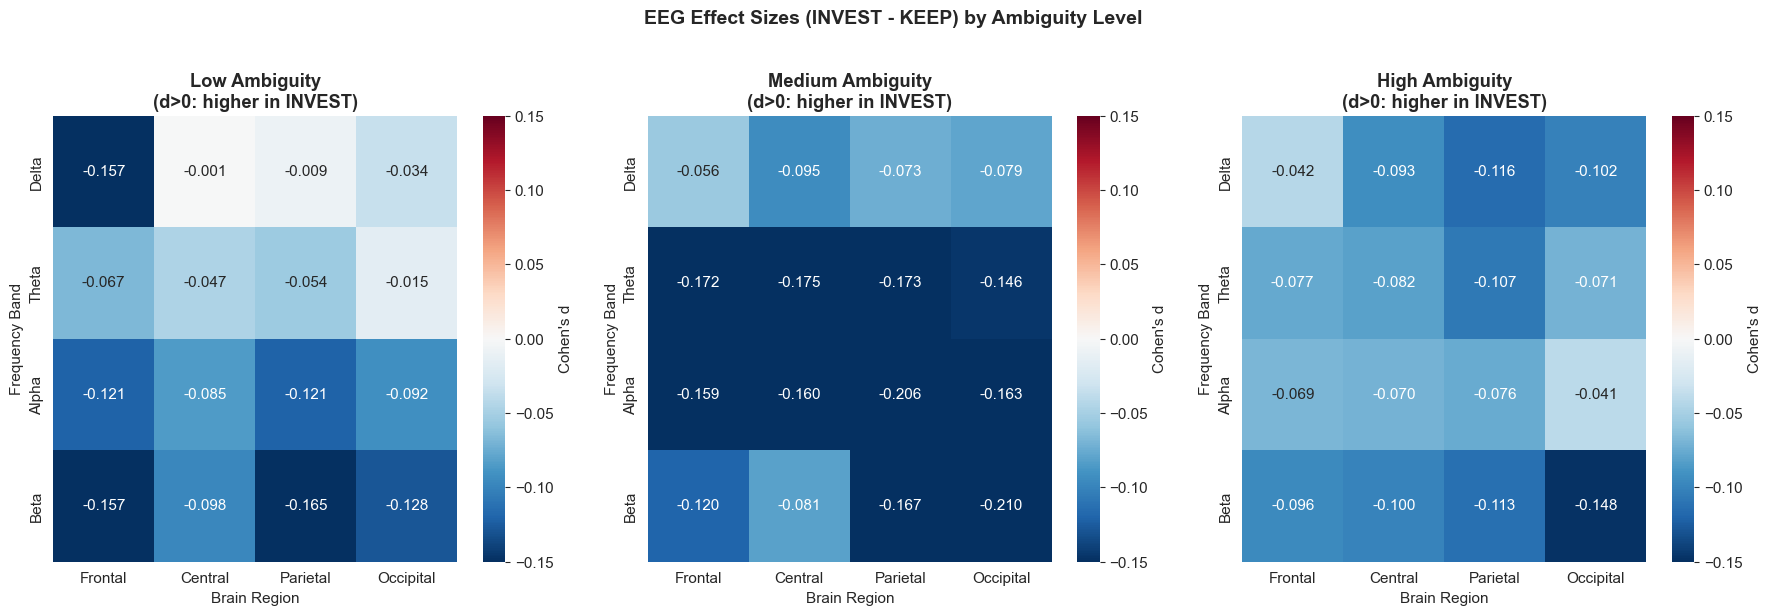

In [5]:
# Heatmap: Effect sizes by Band × Region × Ambiguity
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

band_order = ['Delta', 'Theta', 'Alpha', 'Beta']
region_order = ['Frontal', 'Central', 'Parietal', 'Occipital']

for idx, ambiguity in enumerate(['Low', 'Medium', 'High']):
    ax = axes[idx]
    amb_df = effect_df[effect_df['ambiguity'] == ambiguity]
    
    pivot = amb_df.pivot(index='band', columns='region', values='cohens_d')
    pivot = pivot.reindex(index=band_order, columns=region_order)
    
    sns.heatmap(pivot, cmap='RdBu_r', center=0, annot=True, fmt='.3f',
                vmin=-0.15, vmax=0.15, ax=ax, cbar_kws={'label': "Cohen's d"})
    ax.set_title(f'{ambiguity} Ambiguity\n(d>0: higher in INVEST)', fontweight='bold')
    ax.set_xlabel('Brain Region')
    ax.set_ylabel('Frequency Band')

plt.suptitle('EEG Effect Sizes (INVEST - KEEP) by Ambiguity Level', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eeg_effect_sizes_by_ambiguity.png', dpi=300, bbox_inches='tight')
plt.show()

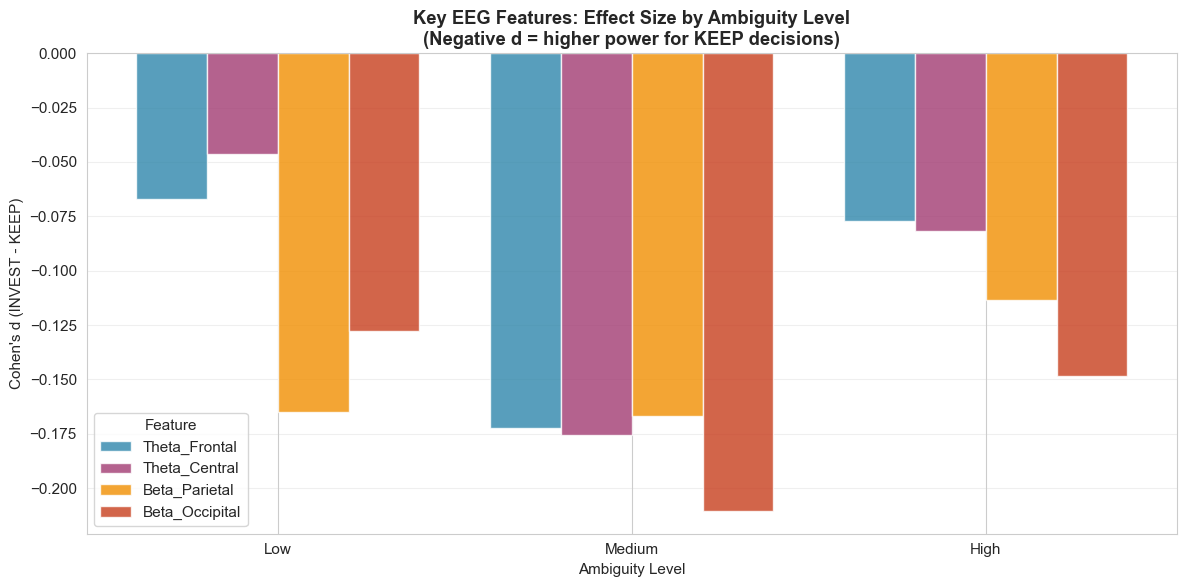

In [6]:
# Bar plot: Effect size change across ambiguity for key features
key_features = ['eeg_Theta_Frontal', 'eeg_Theta_Central', 'eeg_Beta_Parietal', 'eeg_Beta_Occipital']

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(3)  # Low, Medium, High
width = 0.2
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

for i, feat in enumerate(key_features):
    feat_df = effect_df[effect_df['feature'] == feat]
    # Ensure correct order
    values = [feat_df[feat_df['ambiguity'] == amb]['cohens_d'].values[0] for amb in ['Low', 'Medium', 'High']]
    offset = (i - len(key_features)/2 + 0.5) * width
    ax.bar(x + offset, values, width, label=feat.replace('eeg_', ''), color=colors[i], alpha=0.8)

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(['Low', 'Medium', 'High'])
ax.set_xlabel('Ambiguity Level')
ax.set_ylabel("Cohen's d (INVEST - KEEP)")
ax.set_title('Key EEG Features: Effect Size by Ambiguity Level\n(Negative d = higher power for KEEP decisions)', fontweight='bold')
ax.legend(title='Feature')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'key_eeg_features_by_ambiguity.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Analysis 2: EEG-Only Accuracy by Ambiguity Level

Does EEG contribute more when behavioral cues are less informative (high ambiguity)?

In [7]:
def run_single_modality_cv(X, y, subjects):
    """Run LOSO-CV for a single modality."""
    logo = LeaveOneGroupOut()
    accuracies = []
    
    for train_idx, test_idx in logo.split(X, y, subjects):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        clf = RandomForestClassifier(n_estimators=100, max_depth=5, 
                                     class_weight='balanced', random_state=42, n_jobs=-1)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        accuracies.append(accuracy_score(y_test, y_pred))
    
    return np.array(accuracies)

# Run EEG-only, Behavior-only, and Physio-only for each ambiguity level
modality_results = []

imputer = SimpleImputer(strategy='mean')

for ambiguity in ['Low', 'Medium', 'High']:
    print(f"\nProcessing {ambiguity} ambiguity...")
    amb_df = merged_with_eeg[merged_with_eeg['ambiguity_group'] == ambiguity]
    
    y = amb_df['outcome'].values
    subjects = amb_df['subject_id'].values
    
    # EEG only
    X_eeg = imputer.fit_transform(amb_df[eeg_cols])
    eeg_accs = run_single_modality_cv(X_eeg, y, subjects)
    
    # Behavior only
    X_behavior = imputer.fit_transform(amb_df[behavior_cols])
    behavior_accs = run_single_modality_cv(X_behavior, y, subjects)
    
    # Physio (pupil) only
    X_physio = imputer.fit_transform(amb_df[physio_cols])
    physio_accs = run_single_modality_cv(X_physio, y, subjects)
    
    # Gaze only
    X_gaze = imputer.fit_transform(amb_df[gaze_cols])
    gaze_accs = run_single_modality_cv(X_gaze, y, subjects)
    
    for modality, accs in [('EEG', eeg_accs), ('Behavior', behavior_accs), 
                           ('Physio', physio_accs), ('Gaze', gaze_accs)]:
        modality_results.append({
            'ambiguity': ambiguity,
            'modality': modality,
            'accuracy_mean': accs.mean(),
            'accuracy_std': accs.std(),
            'accuracy_sem': accs.std() / np.sqrt(len(accs)),
            'n_subjects': len(accs)
        })

modality_acc_df = pd.DataFrame(modality_results)
print("\nDone!")


Processing Low ambiguity...

Processing Medium ambiguity...

Processing High ambiguity...

Done!


In [8]:
print("\n" + "="*70)
print("SINGLE-MODALITY ACCURACY BY AMBIGUITY LEVEL")
print("="*70)
print("\nQuestion: Does EEG contribute MORE when behavioral cues are less informative?\n")

pivot = modality_acc_df.pivot(index='modality', columns='ambiguity', values='accuracy_mean')
pivot = pivot[['Low', 'Medium', 'High']]  # Ensure order
print(pivot.round(3).to_string())

# Compute relative performance (compared to behavior)
print("\n" + "-"*50)
print("Relative to Behavior (EEG acc / Behavior acc):")
for amb in ['Low', 'Medium', 'High']:
    eeg_acc = modality_acc_df[(modality_acc_df['modality'] == 'EEG') & 
                              (modality_acc_df['ambiguity'] == amb)]['accuracy_mean'].values[0]
    beh_acc = modality_acc_df[(modality_acc_df['modality'] == 'Behavior') & 
                              (modality_acc_df['ambiguity'] == amb)]['accuracy_mean'].values[0]
    ratio = eeg_acc / beh_acc
    print(f"  {amb}: {ratio:.3f} (EEG={eeg_acc:.3f}, Behavior={beh_acc:.3f})")


SINGLE-MODALITY ACCURACY BY AMBIGUITY LEVEL

Question: Does EEG contribute MORE when behavioral cues are less informative?

ambiguity    Low  Medium   High
modality                       
Behavior   0.641   0.658  0.661
EEG        0.704   0.612  0.471
Gaze       0.700   0.628  0.642
Physio     0.542   0.516  0.589

--------------------------------------------------
Relative to Behavior (EEG acc / Behavior acc):
  Low: 1.098 (EEG=0.704, Behavior=0.641)
  Medium: 0.930 (EEG=0.612, Behavior=0.658)
  High: 0.712 (EEG=0.471, Behavior=0.661)


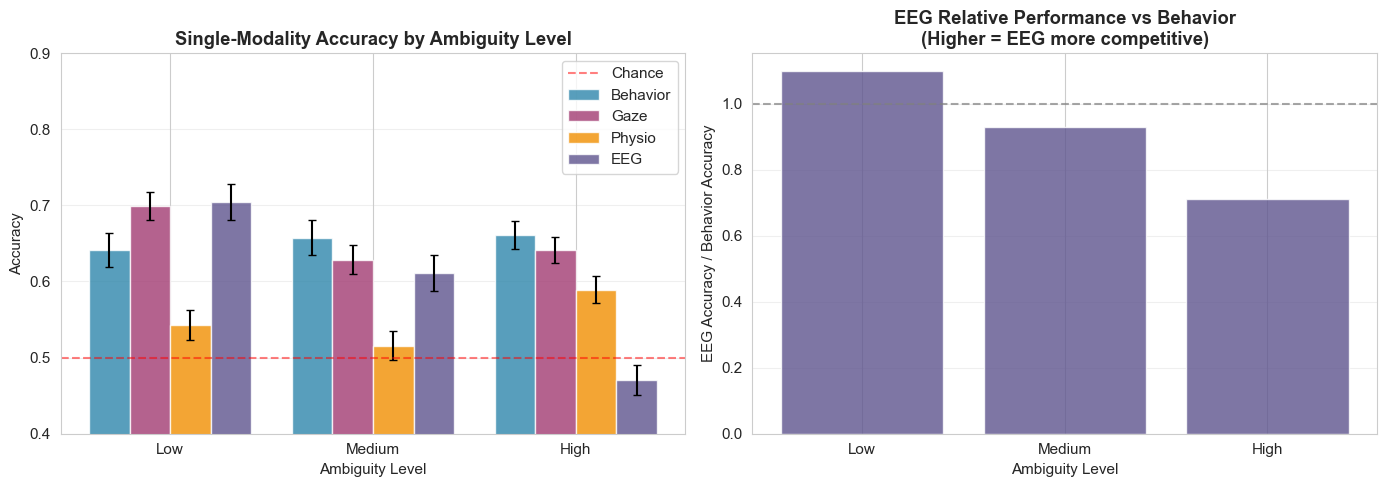

In [9]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy by modality and ambiguity
ax = axes[0]
modalities = ['Behavior', 'Gaze', 'Physio', 'EEG']
colors = {'Behavior': '#2E86AB', 'Gaze': '#A23B72', 'Physio': '#F18F01', 'EEG': '#5E548E'}

x = np.arange(3)
width = 0.2

for i, modality in enumerate(modalities):
    mod_df = modality_acc_df[modality_acc_df['modality'] == modality]
    values = [mod_df[mod_df['ambiguity'] == amb]['accuracy_mean'].values[0] for amb in ['Low', 'Medium', 'High']]
    errors = [mod_df[mod_df['ambiguity'] == amb]['accuracy_sem'].values[0] for amb in ['Low', 'Medium', 'High']]
    offset = (i - len(modalities)/2 + 0.5) * width
    ax.bar(x + offset, values, width, yerr=errors, label=modality, 
           color=colors[modality], alpha=0.8, capsize=3)

ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
ax.set_xticks(x)
ax.set_xticklabels(['Low', 'Medium', 'High'])
ax.set_xlabel('Ambiguity Level')
ax.set_ylabel('Accuracy')
ax.set_title('Single-Modality Accuracy by Ambiguity Level', fontweight='bold')
ax.legend()
ax.set_ylim([0.4, 0.9])
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: EEG relative performance
ax = axes[1]
eeg_rel = []
for amb in ['Low', 'Medium', 'High']:
    eeg_acc = modality_acc_df[(modality_acc_df['modality'] == 'EEG') & 
                              (modality_acc_df['ambiguity'] == amb)]['accuracy_mean'].values[0]
    beh_acc = modality_acc_df[(modality_acc_df['modality'] == 'Behavior') & 
                              (modality_acc_df['ambiguity'] == amb)]['accuracy_mean'].values[0]
    eeg_rel.append(eeg_acc / beh_acc)

ax.bar(['Low', 'Medium', 'High'], eeg_rel, color='#5E548E', alpha=0.8)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.7, label='Equal to Behavior')
ax.set_xlabel('Ambiguity Level')
ax.set_ylabel('EEG Accuracy / Behavior Accuracy')
ax.set_title('EEG Relative Performance vs Behavior\n(Higher = EEG more competitive)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'modality_accuracy_by_ambiguity.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Analysis 3: Detailed Theta Analysis

Deep dive into theta band across regions and ambiguity levels.

In [10]:
# Group-level theta power comparison
theta_cols = [c for c in eeg_cols if 'Theta' in c]

print("\n" + "="*70)
print("THETA POWER BY AMBIGUITY AND CHOICE")
print("="*70)

for col in theta_cols:
    print(f"\n{col}:")
    for amb in ['Low', 'Medium', 'High']:
        amb_df = merged_with_eeg[merged_with_eeg['ambiguity_group'] == amb]
        invest_mean = amb_df[amb_df['outcome'] == 1][col].mean()
        keep_mean = amb_df[amb_df['outcome'] == 0][col].mean()
        diff = keep_mean - invest_mean
        print(f"  {amb}: INVEST={invest_mean:.4f}, KEEP={keep_mean:.4f}, diff={diff:+.4f}")


THETA POWER BY AMBIGUITY AND CHOICE

eeg_Theta_Frontal:
  Low: INVEST=0.0366, KEEP=0.0412, diff=+0.0046
  Medium: INVEST=0.0340, KEEP=0.0438, diff=+0.0098
  High: INVEST=0.0345, KEEP=0.0406, diff=+0.0061

eeg_Theta_Central:
  Low: INVEST=0.0332, KEEP=0.0364, diff=+0.0031
  Medium: INVEST=0.0312, KEEP=0.0411, diff=+0.0100
  High: INVEST=0.0307, KEEP=0.0395, diff=+0.0088

eeg_Theta_Parietal:
  Low: INVEST=0.0352, KEEP=0.0389, diff=+0.0036
  Medium: INVEST=0.0328, KEEP=0.0420, diff=+0.0091
  High: INVEST=0.0326, KEEP=0.0388, diff=+0.0062

eeg_Theta_Occipital:
  Low: INVEST=0.0398, KEEP=0.0411, diff=+0.0013
  Medium: INVEST=0.0365, KEEP=0.0455, diff=+0.0090
  High: INVEST=0.0377, KEEP=0.0422, diff=+0.0045


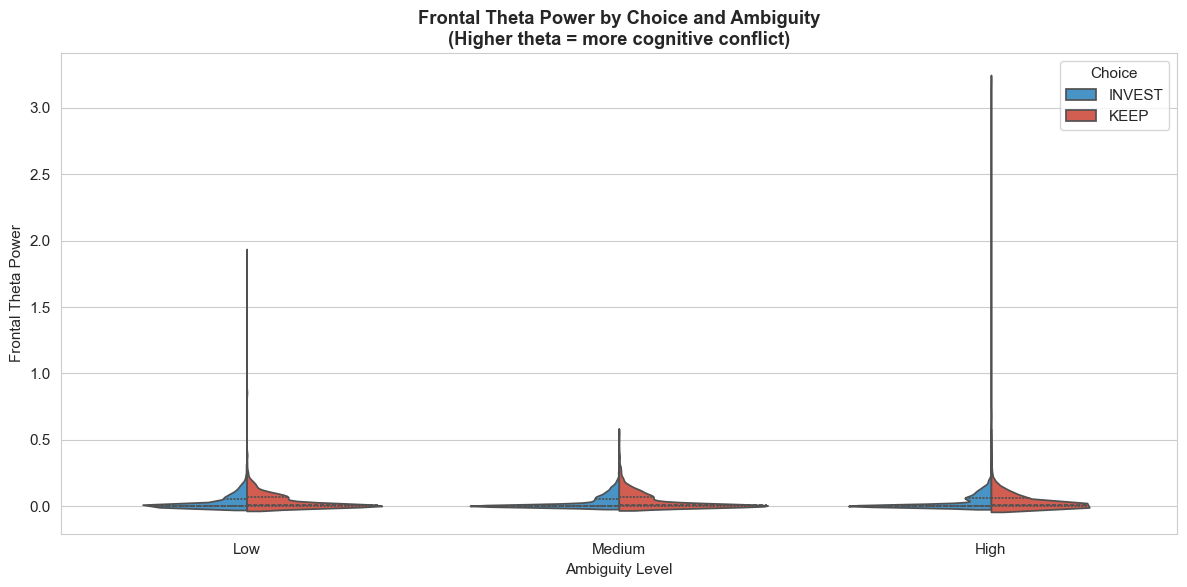

In [11]:
# Violin plot: Theta-Frontal distribution by choice and ambiguity
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for seaborn
plot_df = merged_with_eeg[['ambiguity_group', 'outcome', 'eeg_Theta_Frontal']].copy()
plot_df['choice'] = plot_df['outcome'].map({0: 'KEEP', 1: 'INVEST'})
plot_df['ambiguity_group'] = pd.Categorical(plot_df['ambiguity_group'], 
                                            categories=['Low', 'Medium', 'High'], ordered=True)

sns.violinplot(data=plot_df, x='ambiguity_group', y='eeg_Theta_Frontal', 
               hue='choice', split=True, inner='quart', palette={'INVEST': '#3498DB', 'KEEP': '#E74C3C'},
               ax=ax)

ax.set_xlabel('Ambiguity Level')
ax.set_ylabel('Frontal Theta Power')
ax.set_title('Frontal Theta Power by Choice and Ambiguity\n(Higher theta = more cognitive conflict)', fontweight='bold')
ax.legend(title='Choice')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'theta_frontal_violin.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Analysis 4: Fronto-Parietal Coherence (Placeholder)

This requires raw EEG data to compute phase-locking values. Adding structure for future implementation.

In [12]:
# Load raw EEG for coherence analysis
print("\n" + "="*70)
print("FRONTO-PARIETAL COHERENCE ANALYSIS")
print("="*70)

EEG_PATH = Path('../../data/eeg/preprocessed_eeg_review.pkl')

if EEG_PATH.exists():
    print("Loading raw EEG data for coherence analysis...")
    with open(EEG_PATH, 'rb') as f:
        raw_eeg_df = pickle.load(f)
    print(f"Loaded {len(raw_eeg_df)} trials")
    print(f"EEG shape per trial: {raw_eeg_df.iloc[0]['review_eeg'].shape}")
else:
    print("Raw EEG file not found. Skipping coherence analysis.")
    raw_eeg_df = None


FRONTO-PARIETAL COHERENCE ANALYSIS
Loading raw EEG data for coherence analysis...
Loaded 11806 trials
EEG shape per trial: (20, 512)


In [13]:
def compute_coherence(signal1, signal2, fs=256, nperseg=128):
    """Compute magnitude-squared coherence between two signals."""
    freqs, coh = signal.coherence(signal1, signal2, fs=fs, nperseg=nperseg)
    return freqs, coh

def compute_band_coherence(signal1, signal2, band=(4, 8), fs=256):
    """Compute average coherence within a frequency band."""
    freqs, coh = compute_coherence(signal1, signal2, fs=fs)
    band_mask = (freqs >= band[0]) & (freqs <= band[1])
    return np.mean(coh[band_mask])

if raw_eeg_df is not None:
    # Get channel indices
    fz_idx = CHANNEL_NAMES.index('Fz')
    pz_idx = CHANNEL_NAMES.index('Pz')
    
    print(f"Computing Fz-Pz theta coherence...")
    print(f"  Fz index: {fz_idx}, Pz index: {pz_idx}")
    
    # Sample a few trials to check
    sample_trials = raw_eeg_df.head(100)
    coherences = []
    
    for _, row in sample_trials.iterrows():
        eeg = row['review_eeg']  # (channels, time)
        fz_signal = eeg[fz_idx, :]
        pz_signal = eeg[pz_idx, :]
        
        theta_coh = compute_band_coherence(fz_signal, pz_signal, band=(4, 8))
        coherences.append(theta_coh)
    
    print(f"  Sample theta coherence (Fz-Pz): {np.mean(coherences):.4f} ± {np.std(coherences):.4f}")
    print("\n  (Full coherence analysis would extract this for all trials and compare by choice/ambiguity)")

Computing Fz-Pz theta coherence...
  Fz index: 12, Pz index: 10
  Sample theta coherence (Fz-Pz): 0.1795 ± 0.0941

  (Full coherence analysis would extract this for all trials and compare by choice/ambiguity)


In [14]:
# Extract coherence features for all trials (if raw EEG available)
if raw_eeg_df is not None:
    print("\nExtracting Fz-Pz theta coherence for all trials...")
    
    coherence_data = []
    
    for idx, row in raw_eeg_df.iterrows():
        if idx % 2000 == 0:
            print(f"  Processing trial {idx}/{len(raw_eeg_df)}...")
        
        eeg = row['review_eeg']
        trial_id = f"{row['trial_id']}_{row['subject_date_id']}"
        
        # Fz-Pz theta coherence
        fz_pz_theta = compute_band_coherence(eeg[fz_idx, :], eeg[pz_idx, :], band=(4, 8))
        
        # F3-P3 theta coherence (left hemisphere)
        f3_idx = CHANNEL_NAMES.index('F3')
        p3_idx = CHANNEL_NAMES.index('P3')
        f3_p3_theta = compute_band_coherence(eeg[f3_idx, :], eeg[p3_idx, :], band=(4, 8))
        
        # F4-P4 theta coherence (right hemisphere)
        f4_idx = CHANNEL_NAMES.index('F4')
        p4_idx = CHANNEL_NAMES.index('P4')
        f4_p4_theta = compute_band_coherence(eeg[f4_idx, :], eeg[p4_idx, :], band=(4, 8))
        
        coherence_data.append({
            'trial_id': trial_id,
            'fz_pz_theta_coh': fz_pz_theta,
            'f3_p3_theta_coh': f3_p3_theta,
            'f4_p4_theta_coh': f4_p4_theta,
            'mean_fp_theta_coh': np.mean([fz_pz_theta, f3_p3_theta, f4_p4_theta])
        })
    
    coherence_df = pd.DataFrame(coherence_data)
    print(f"\nExtracted coherence for {len(coherence_df)} trials")
    
    # Merge with behavioral data
    merged_coherence = merged_with_eeg.merge(coherence_df, on='trial_id', how='inner')
    print(f"Merged dataset: {len(merged_coherence)} trials")


Extracting Fz-Pz theta coherence for all trials...
  Processing trial 0/11806...
  Processing trial 2000/11806...
  Processing trial 4000/11806...
  Processing trial 6000/11806...
  Processing trial 8000/11806...
  Processing trial 10000/11806...

Extracted coherence for 11806 trials
Merged dataset: 10802 trials


In [15]:
# Analyze coherence by choice and ambiguity
if raw_eeg_df is not None and len(coherence_df) > 0:
    print("\n" + "="*70)
    print("FRONTO-PARIETAL THETA COHERENCE RESULTS")
    print("="*70)
    
    coh_cols = ['fz_pz_theta_coh', 'f3_p3_theta_coh', 'f4_p4_theta_coh', 'mean_fp_theta_coh']
    
    coh_results = []
    for amb in ['Low', 'Medium', 'High']:
        amb_df = merged_coherence[merged_coherence['ambiguity_group'] == amb]
        invest_df = amb_df[amb_df['outcome'] == 1]
        keep_df = amb_df[amb_df['outcome'] == 0]
        
        for col in coh_cols:
            invest_vals = invest_df[col].dropna()
            keep_vals = keep_df[col].dropna()
            
            d = compute_cohens_d(invest_vals, keep_vals)
            t_stat, p_val = stats.ttest_ind(invest_vals, keep_vals)
            
            coh_results.append({
                'ambiguity': amb,
                'feature': col,
                'cohens_d': d,
                'p_value': p_val,
                'invest_mean': invest_vals.mean(),
                'keep_mean': keep_vals.mean()
            })
    
    coh_results_df = pd.DataFrame(coh_results)
    
    # Focus on mean fronto-parietal coherence
    print("\nMean Fronto-Parietal Theta Coherence by Ambiguity and Choice:")
    mean_fp = coh_results_df[coh_results_df['feature'] == 'mean_fp_theta_coh']
    print(mean_fp[['ambiguity', 'cohens_d', 'p_value', 'invest_mean', 'keep_mean']].to_string(index=False))


FRONTO-PARIETAL THETA COHERENCE RESULTS

Mean Fronto-Parietal Theta Coherence by Ambiguity and Choice:
ambiguity  cohens_d  p_value  invest_mean  keep_mean
      Low -0.015355 0.721118     0.430038   0.433444
   Medium  0.084146 0.019810     0.433981   0.415153
     High -0.003096 0.926287     0.430198   0.430891


## 6. Save Results

In [16]:
# Save all results
effect_df.to_csv(OUTPUT_DIR / 'eeg_effect_sizes_by_ambiguity.csv', index=False)
modality_acc_df.to_csv(OUTPUT_DIR / 'modality_accuracy_by_ambiguity.csv', index=False)

if raw_eeg_df is not None and 'coh_results_df' in dir():
    coh_results_df.to_csv(OUTPUT_DIR / 'coherence_results_by_ambiguity.csv', index=False)
    coherence_df.to_csv(OUTPUT_DIR / 'coherence_features_all_trials.csv', index=False)

print("\n" + "="*70)
print("FILES SAVED")
print("="*70)
print(f"  - {OUTPUT_DIR / 'eeg_effect_sizes_by_ambiguity.csv'}")
print(f"  - {OUTPUT_DIR / 'modality_accuracy_by_ambiguity.csv'}")
print(f"  - {OUTPUT_DIR / 'eeg_effect_sizes_by_ambiguity.png'}")
print(f"  - {OUTPUT_DIR / 'key_eeg_features_by_ambiguity.png'}")
print(f"  - {OUTPUT_DIR / 'modality_accuracy_by_ambiguity.png'}")
print(f"  - {OUTPUT_DIR / 'theta_frontal_violin.png'}")


FILES SAVED
  - ../../data/results/main/eeg_integration/eeg_deep_dive/eeg_effect_sizes_by_ambiguity.csv
  - ../../data/results/main/eeg_integration/eeg_deep_dive/modality_accuracy_by_ambiguity.csv
  - ../../data/results/main/eeg_integration/eeg_deep_dive/eeg_effect_sizes_by_ambiguity.png
  - ../../data/results/main/eeg_integration/eeg_deep_dive/key_eeg_features_by_ambiguity.png
  - ../../data/results/main/eeg_integration/eeg_deep_dive/modality_accuracy_by_ambiguity.png
  - ../../data/results/main/eeg_integration/eeg_deep_dive/theta_frontal_violin.png


## 7. Key Findings Summary

In [17]:
print("\n" + "="*70)
print("KEY FINDINGS: EEG DEEP DIVE")
print("="*70)

print("\n1. THETA × AMBIGUITY × CHOICE INTERACTION:")
theta_frontal = effect_df[(effect_df['band'] == 'Theta') & (effect_df['region'] == 'Frontal')]
for amb in ['Low', 'Medium', 'High']:
    d = theta_frontal[theta_frontal['ambiguity'] == amb]['cohens_d'].values[0]
    p = theta_frontal[theta_frontal['ambiguity'] == amb]['p_value'].values[0]
    sig = '*' if p < 0.05 else ''
    print(f"   {amb}: d = {d:.4f}, p = {p:.4f} {sig}")

print("\n2. EEG-ONLY ACCURACY BY AMBIGUITY:")
eeg_only = modality_acc_df[modality_acc_df['modality'] == 'EEG']
for amb in ['Low', 'Medium', 'High']:
    acc = eeg_only[eeg_only['ambiguity'] == amb]['accuracy_mean'].values[0]
    print(f"   {amb}: {acc:.3f}")

print("\n3. STRONGEST EEG EFFECTS (across all ambiguity levels):")
top_effects = effect_df.groupby('feature')['abs_d'].mean().sort_values(ascending=False).head(5)
for feat, d in top_effects.items():
    print(f"   {feat}: mean |d| = {d:.4f}")

print(f"\n" + "="*70)
print(f"Analysis completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)


KEY FINDINGS: EEG DEEP DIVE

1. THETA × AMBIGUITY × CHOICE INTERACTION:
   Low: d = -0.0670, p = 0.1193 
   Medium: d = -0.1722, p = 0.0000 *
   High: d = -0.0770, p = 0.0214 *

2. EEG-ONLY ACCURACY BY AMBIGUITY:
   Low: 0.704
   Medium: 0.612
   High: 0.471

3. STRONGEST EEG EFFECTS (across all ambiguity levels):
   eeg_Beta_Occipital: mean |d| = 0.1623
   eeg_Beta_Parietal: mean |d| = 0.1484
   eeg_Alpha_Parietal: mean |d| = 0.1345
   eeg_Beta_Frontal: mean |d| = 0.1241
   eeg_Alpha_Frontal: mean |d| = 0.1162

Analysis completed: 2026-04-06 11:11:07
